# PCA of a swap portfolio

Imports and notebook setup

In [43]:
%load_ext autoreload
%autoreload 2

import sys
import os
# Adds the parent directory to the path so 'core' is visible
sys.path.append(os.path.abspath(".."))

from core.solvedcurve import SolvedCurve
from core.swap import Swap 
from core.dual import Dual 
from datetime import datetime, timedelta
from core.portfolio import Portfolio

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
from core.solvedcurve import SolvedCurve
from core.swap import Swap 
from core.dual import Dual 
from datetime import datetime, timedelta
from core.portfolio import Portfolio

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Setup & caliberate a curve

In [44]:
nodes = {
    datetime(2022, 1, 1): Dual(1, {"v0": 1}),
    datetime(2024, 1, 1): Dual(1, {"v1": 1}),
    datetime(2027, 1, 1): Dual(1, {"v2": 1}),
    datetime(2032, 1, 1): Dual(1, {"v3": 1}),
    datetime(2052, 1, 1): Dual(1, {"v4": 1}),
}
swaps = {
    Swap(datetime(2022, 1, 1), 12*2, 12, 12): 1.20,
    Swap(datetime(2022, 1, 1), 12*5, 12, 12): 1.66,
    Swap(datetime(2022, 1, 1), 12*10, 12, 12): 1.93,
    Swap(datetime(2022, 1, 1), 12*30, 12, 12): 2.20,
}
s_cv = SolvedCurve(nodes=nodes, interpolation="log_linear", swaps=list(swaps.keys()), obj_rates=list(swaps.values()))
s_cv.iterate()

'tolerance reached (levenberg_marquardt) after 12 iterations. f:1.43219494212483e-18'

Build covariance matrix Q from historical data

In [45]:
historical_rates = pd.DataFrame({
    "2Y": [1.199, 1.228, 1.210, 1.215, 1.203, 1.159, 1.175, 1.188, 1.159, 1.100],
    "5Y": [1.663, 1.696, 1.665, 1.680, 1.677, 1.657, 1.673, 1.676, 1.653, 1.600],
    "10Y": [1.928, 1.945, 1.934, 1.93, 1.934, 1.931, 1.958, 1.972, 1.932, 1.900],
    "30Y": [2.201, 2.217, 2.228, 2.239, 2.226, 2.235, 2.242, 2.236, 2.22, 2.200],
})
daily_changes_bp = historical_rates.diff(periods=-1) * 100
Q = daily_changes_bp.cov()
print(Q)
Q = Q.to_numpy()

          2Y      5Y       10Y       30Y
2Y   8.66000  7.3775  5.136250  2.185000
5Y   7.37750  7.3075  4.730000  2.157500
10Y  5.13625  4.7300  4.891111  1.762361
30Y  2.18500  2.1575  1.762361  1.861111


Portfolio of swaps

In [56]:
portfolio = Portfolio(objects=[
    Swap(datetime(2022,1,1), 12*2, 12, 12, notional=-1.272e6),
    Swap(datetime(2022,1,1), 12*5, 12, 12, notional=313545),
    Swap(datetime(2022,1,1), 12*10, 12, 12, notional=109931),
    Swap(datetime(2022,1,1), 12*30, 12, 12, notional=27160),
])

print(f'{portfolio.npv(s_cv).real=}')
print(f'{portfolio.risk(s_cv).real=}')

c = portfolio.covar(s_cv, Q)
print(f'Portfolio standard deviation: {c=}')

portfolio.npv(s_cv).real=0.0
portfolio.risk(s_cv).real=array([[-249.89],
       [ 150.  ],
       [ 100.  ],
       [  59.99]])
Portfolio standard deviation: c=295.62914363837115


### PCA of Portfolio

We take the covariance matrix Q, and transform it into orthogonal Eigen vectors

- Each Eigen vector represents a spread/change in data and is independent of the others i.e `ei_T . Q . ej = 0`
- Eigen values represent the spread(variance) along the axes eigen vector.
- Larger Eigen values mean the spread/change in data is most spread along ei
- Smaller Eigen values mean negligible/smaller/ignoreable spread along ej axis

In [94]:
print('PCA of the covariance matrix Q:')
eigen_values, eigen_vectors= Portfolio.pca(Q)

df = pd.DataFrame(eigen_vectors, index=['2Y', '5Y', '10Y', '30Y'])
df.loc['lambda', :] = eigen_values
df.columns = [f"PC{i+1}" for i in range(df.shape[1])]

df.style.format("{:,.2f}")

PCA of the covariance matrix Q:


,PC1,PC2,PC3,PC4
2Y,-0.65,0.41,-0.06,-0.64
5Y,-0.59,0.26,0.18,0.74
10Y,-0.44,-0.73,-0.53,0.03
30Y,-0.20,-0.49,0.83,-0.19
lambda,19.58,1.53,1.06,0.55


#### Observation
From the results above, we can tell 

1. PC1 is the dominant axes for the spread in daily rate changes, with variance(lambda) 19.58. 
2. PC1 vector shows that it moves all 4 pillars in the same direction by similar magnitude, almost characterising a parallel shift in the curve
3. PC2, PC3, PC4 are much less dominant factors 
4. PC2 characterises a move in 2Y, 5Y and an oppsoite move in 10Y,30Y signalling short to long curve steepening
5. PC3 characterises a 10s30s curve steepening move
6. PC4 characterises a 2s5s curve steepening move

#### Plotting the PC values

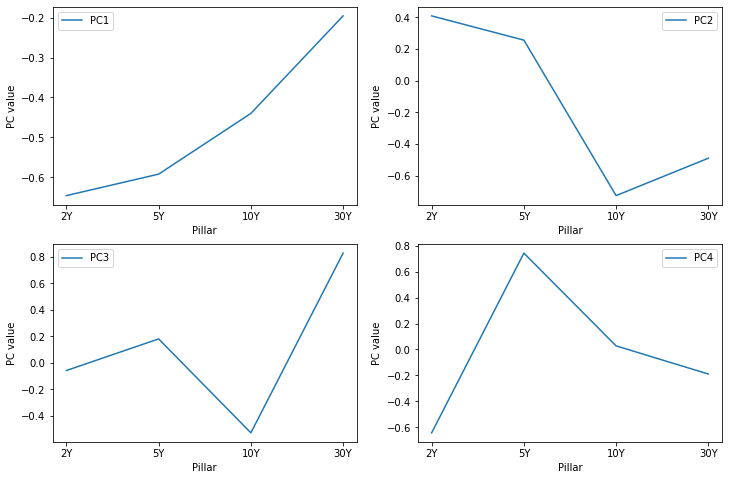

In [95]:
fix, ax = plt.subplots(2, 2, figsize=(12, 8))

for i in range(df.shape[1]):
    splt = ax[i//2, i%2]
    splt.plot(df.loc[df.index != 'lambda', f'PC{i+1}'], label=f'PC{i+1}')
    splt.set_xlabel('Pillar')
    splt.set_ylabel('PC value')
    splt.legend()

plt.show()

#### Historical multipliers

We calculate the daily rate change in bp, along each of our eigen_vector/PC axes (columns)

In [96]:
Portfolio.historical_multipliers(Q, daily_changes_bp)

array([[ 6.15, -0.41, -0.77, -0.15],
       [-2.  ,  0.87, -0.94,  1.56],
       [ 2.51, -0.74, -1.27, -0.39],
       [ 0.23, -0.18,  1.36, -0.62],
       [-2.72,  2.14, -0.7 , -0.98],
       [ 4.57,  0.84,  0.74,  0.08],
       [ 2.78, -0.28,  1.35,  0.64],
       [-4.04, -2.31, -0.44, -0.17],
       [-7.49,  0.06,  0.68,  0.04],
       [  nan,   nan,   nan,   nan]])